In [27]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

import xgboost as xgb

import joblib
import os

sns.set_style("whitegrid")


from sklearn.metrics import f1_score, precision_score, recall_score

import shap

c:\Users\ASUS\anaconda3\envs\dsai_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the processed dataset
df = pd.read_csv("D:/ShaunakKathavate Github/digital_marketing_campaign_predictor/data/processed/processed_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (8000, 31)


,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,x1_Referral,x1_SEO,x1_Social Media,x2_Awareness,x2_Consideration,x2_Conversion,x2_Retention,x3_IsConfid,x4_ToolConfid,Conversion
0,0.830400,1.391266,0.527784,-1.320998,-0.298267,-1.729507,-1.209000,-0.078303,-1.066014,-0.608829,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1
1,1.702775,-1.142380,-0.388643,0.010679,1.428427,1.205221,-1.010159,-0.562053,-1.550715,-1.309262,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1
2,0.159343,0.101011,-1.217996,1.460971,-0.509946,-1.589758,1.026327,1.435737,-1.723823,0.266712,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1
3,-0.780138,-1.080472,-1.573010,-0.205066,-0.298763,1.554594,-0.386987,1.647165,1.357493,-1.309262,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1
4,1.098823,-0.018599,-1.171591,1.167504,0.101230,-1.729507,-1.344153,1.482702,-1.516094,-0.608829,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1


In [4]:
# Split features and target
X = df.drop("Conversion", axis=1)
y = df["Conversion"]

In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (6400, 30)
Test shape: (1600, 30)


In [6]:
# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [7]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)

cv_scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring='roc_auc')

print("Logistic Regression CV ROC-AUC:", np.mean(cv_scores))

Logistic Regression CV ROC-AUC: 0.7942654392021481


In [8]:
# Random Forest
rf = RandomForestClassifier(random_state=42)

cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')

print("Random Forest CV ROC-AUC:", np.mean(cv_scores))

Random Forest CV ROC-AUC: 0.8151458742300143


In [9]:
# XGBoost
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')

print("XGBoost CV ROC-AUC:", np.mean(cv_scores))

XGBoost CV ROC-AUC: 0.8162853403732033


In [10]:
# Hyperparameter tuning for Random Forest
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_random.fit(X_train, y_train)

print("Best RF Params:", rf_random.best_params_)
print("Best RF Score:", rf_random.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 8}
Best RF Score: 0.8243676526997451


In [11]:
# Hyperparameter tuning for XGBoost
xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=xgb_params,
    n_iter=20,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_random.fit(X_train, y_train)

print("Best XGB Params:", xgb_random.best_params_)
print("Best XGB Score:", xgb_random.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGB Params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best XGB Score: 0.8330659536541889


In [12]:
# Choose best model
best_model = xgb_random.best_estimator_

best_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [13]:
# Evaluate on test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.81      0.07      0.12       198
           1       0.88      1.00      0.94      1402

    accuracy                           0.88      1600
   macro avg       0.85      0.53      0.53      1600
weighted avg       0.87      0.88      0.84      1600

ROC-AUC: 0.818851856654995


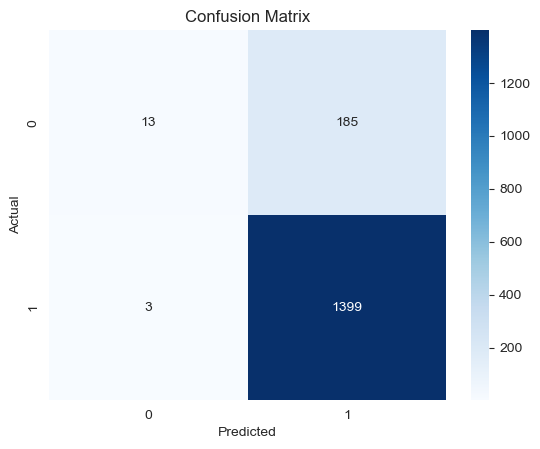

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

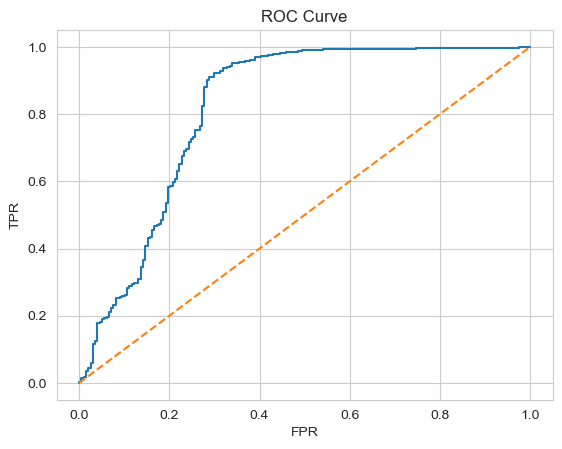

In [15]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

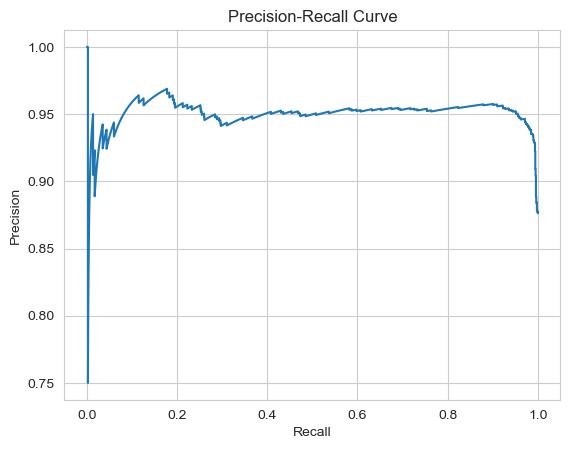

In [16]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [17]:
os.makedirs("D:/ShaunakKathavate Github/digital_marketing_campaign_predictor/models", exist_ok=True)

joblib.dump(best_model, "D:/ShaunakKathavate Github/digital_marketing_campaign_predictor/models/xgb_random_bfm.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


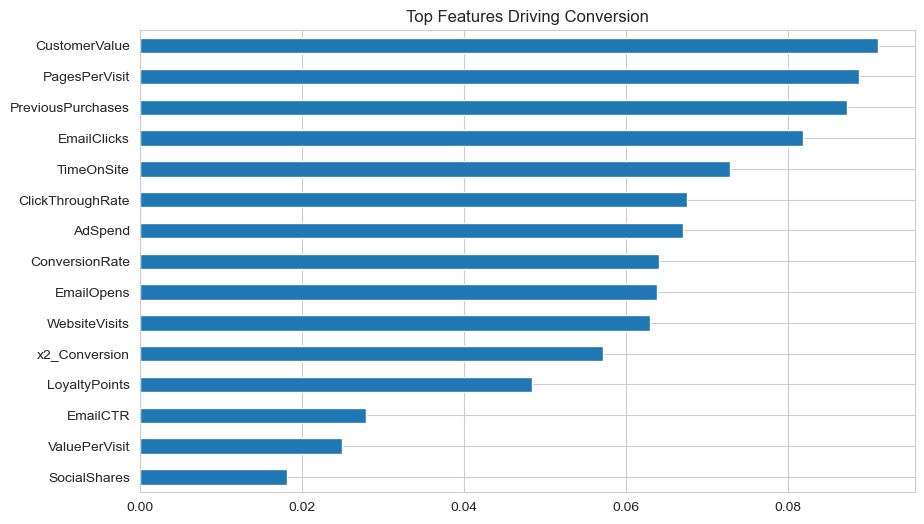

In [18]:
# Feature Importance
importances = best_model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='barh')
plt.title("Top Features Driving Conversion")
plt.gca().invert_yaxis()
plt.show()

# Threshold Tuning

In [21]:
# Threshold Analysis
y_prob = best_model.predict_proba(X_test)[:,1]

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    results.append([t, precision, recall, f1])

results_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "F1"])
print(results_df)

    Threshold  Precision    Recall        F1
0        0.10   0.876250  1.000000  0.934044
1        0.15   0.876798  1.000000  0.934355
2        0.20   0.876798  1.000000  0.934355
3        0.25   0.877347  1.000000  0.934667
4        0.30   0.877193  0.998573  0.933956
5        0.35   0.878294  0.998573  0.934579
6        0.40   0.878769  0.997860  0.934536
7        0.45   0.880982  0.997860  0.935786
8        0.50   0.883207  0.997860  0.937040
9        0.55   0.887548  0.996434  0.938844
10       0.60   0.896021  0.995720  0.943243
11       0.65   0.909387  0.995007  0.950272
12       0.70   0.924353  0.993581  0.957717
13       0.75   0.943292  0.972896  0.957865
14       0.80   0.953812  0.927960  0.940709
15       0.85   0.955298  0.823110  0.884291


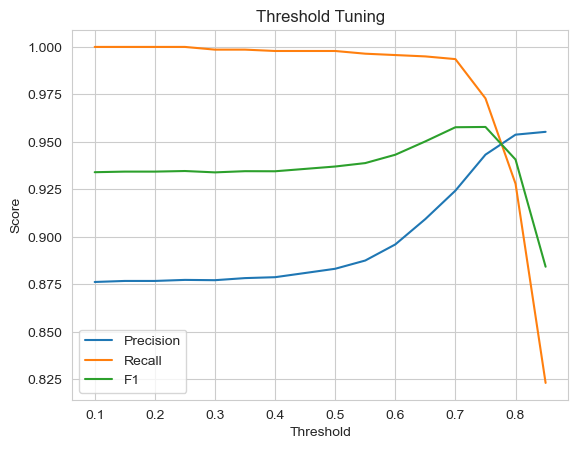

In [22]:
# Plotting threshold tuning results
plt.plot(results_df["Threshold"], results_df["Precision"], label="Precision")
plt.plot(results_df["Threshold"], results_df["Recall"], label="Recall")
plt.plot(results_df["Threshold"], results_df["F1"], label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.show()

In [23]:
# Threshold selection
optimal_threshold = 0.75

y_pred_final = (y_prob >= optimal_threshold).astype(int)

# COST-BASED OPTIMIZATION

In [24]:
# Example business assumptions
profit_per_conversion = 100
cost_per_contact = 10

In [25]:
def calculate_profit(y_true, y_pred):
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()

    profit = (tp * profit_per_conversion) - (fp * cost_per_contact)
    return profit

In [26]:
profits = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    profit = calculate_profit(y_test, y_pred_t)
    profits.append(profit)

results_df["Profit"] = profits
print(results_df.sort_values("Profit", ascending=False).head())

    Threshold  Precision    Recall        F1  Profit
3        0.25   0.877347  1.000000  0.934667  138240
1        0.15   0.876798  1.000000  0.934355  138230
2        0.20   0.876798  1.000000  0.934355  138230
0        0.10   0.876250  1.000000  0.934044  138220
12       0.70   0.924353  0.993581  0.957717  138160


# SHAP EXPLAINABILITY

In [29]:
# SHAP Values for explainability
explainer = shap.TreeExplainer(best_model.get_booster())
shap_values = explainer.shap_values(X_test)

ValueError: could not convert string to float: '[8.765625E-1]'